In [1]:
!pip install pandas numpy matplotlib seaborn statsmodels scikit-learn

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

In [3]:

df = pd.read_csv("rainfall-monthly-total.csv")

df.head()

,month,total_rainfall
0,1982-01,107.1
1,1982-02,27.8
2,1982-03,160.8
3,1982-04,157.0
4,1982-05,102.2


In [4]:
print(df.shape)

print(df.columns)

df.info()

df.describe()

(462, 2)
Index(['month', 'total_rainfall'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 462 entries, 0 to 461
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   month           462 non-null    object 
 1   total_rainfall  462 non-null    float64
dtypes: float64(1), object(1)
memory usage: 7.3+ KB


,total_rainfall
count,462.000000
mean,176.236580
std,113.296793
min,0.200000
25%,89.025000
50%,158.450000
75%,237.950000
max,765.900000


In [5]:
df.isnull().sum()

month             0
total_rainfall    0
dtype: int64

In [6]:

df['Date'] = pd.to_datetime(df['month'])

df.set_index('Date', inplace=True)

df.head()

,month,total_rainfall
Date,,
1982-01-01,1982-01,107.1
1982-02-01,1982-02,27.8
1982-03-01,1982-03,160.8
1982-04-01,1982-04,157.0
1982-05-01,1982-05,102.2


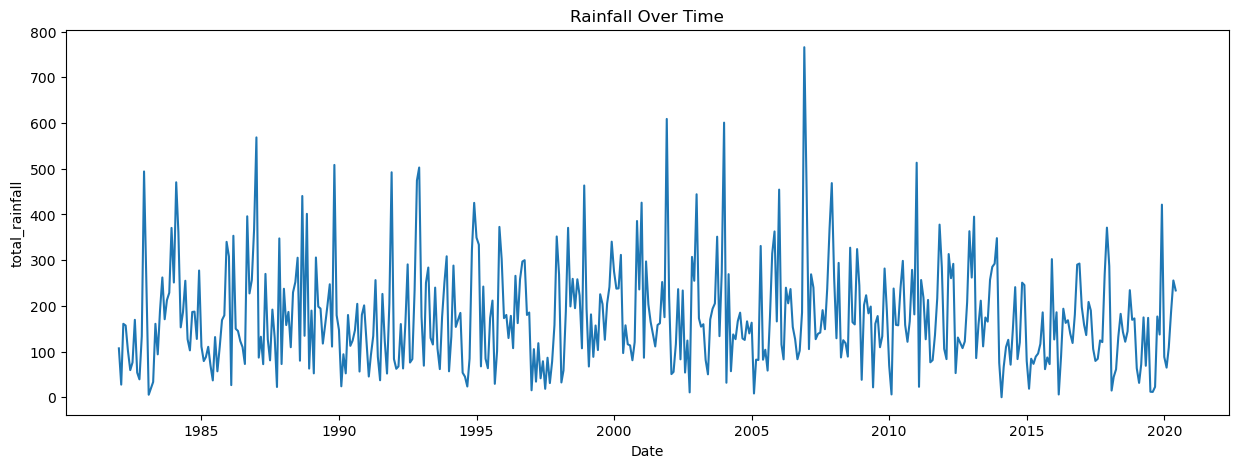

In [8]:
plt.figure(figsize=(15,5))

plt.plot(df['total_rainfall'])

plt.title("Rainfall Over Time")

plt.xlabel("Date")

plt.ylabel("total_rainfall")

plt.show()

In [9]:
train_size = int(len(df) * 0.8)

train = df[:train_size]

test = df[train_size:]

print(train.shape)

print(test.shape)

(369, 2)
(93, 2)


In [22]:
model = SARIMAX(
    train['total_rainfall'],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

model_fit = model.fit()

print(model_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                     total_rainfall   No. Observations:                  369
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -2177.908
Date:                            Wed, 13 May 2026   AIC                           4365.817
Time:                                    20:25:42   BIC                           4385.192
Sample:                                01-01-1982   HQIC                          4373.524
                                     - 09-01-2012                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0680      0.054      1.268      0.205      -0.037       0.173
ma.L1         -0.9997      1.179   

In [23]:
forecast = model_fit.forecast(steps=len(test))

forecast

2012-10-01    171.587309
2012-11-01    284.864813
2012-12-01    329.860206
2013-01-01    253.551491
2013-02-01    116.355551
                 ...    
2020-02-01    123.919271
2020-03-01    202.585940
2020-04-01    178.589892
2020-05-01    188.114470
2020-06-01    152.334203
Freq: MS, Name: predicted_mean, Length: 93, dtype: float64

In [24]:
mae = mean_absolute_error(test['total_rainfall'], forecast)

mse = mean_squared_error(test['total_rainfall'], forecast)

rmse = np.sqrt(mse)

print("MAE:", mae)

print("MSE:", mse)

print("RMSE:", rmse)

MAE: 74.26850423222332
MSE: 8806.137027131765
RMSE: 93.84101995999279


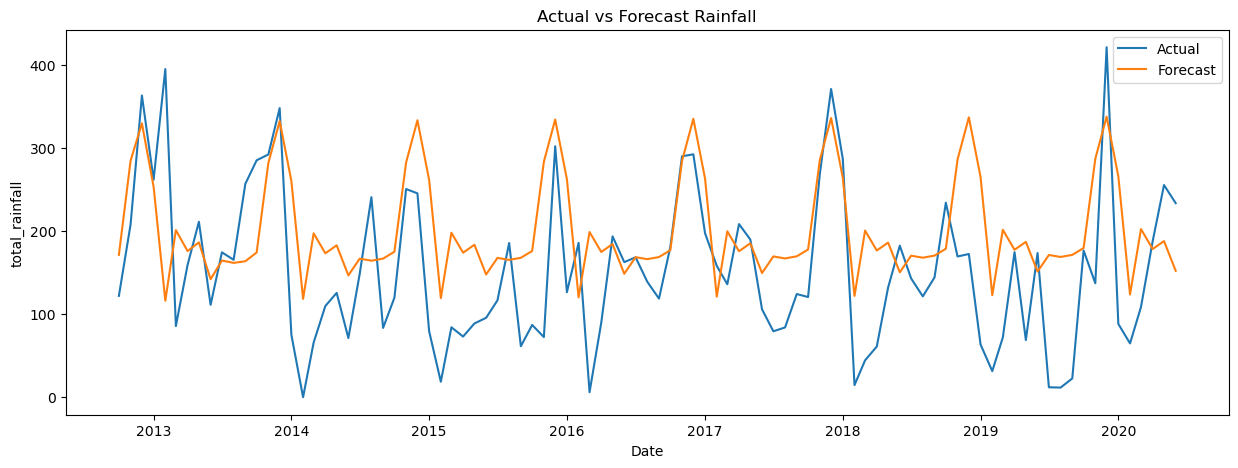

In [25]:
plt.figure(figsize=(15,5))

plt.plot(test.index, test['total_rainfall'], label='Actual')

plt.plot(test.index, forecast, label='Forecast')

plt.title("Actual vs Forecast Rainfall")

plt.xlabel("Date")

plt.ylabel("total_rainfall")

plt.legend()

plt.show()

In [26]:
future_forecast = model_fit.forecast(steps=24)

future_forecast

2012-10-01    171.587309
2012-11-01    284.864813
2012-12-01    329.860206
2013-01-01    253.551491
2013-02-01    116.355551
2013-03-01    201.335244
2013-04-01    176.136039
2013-05-01    186.574370
2013-06-01    142.305470
2013-07-01    164.706956
2013-08-01    161.901780
2013-09-01    163.857989
2013-10-01    174.394414
2013-11-01    282.089906
2013-12-01    332.613755
2014-01-01    260.557044
2014-02-01    118.569044
2014-03-01    197.499412
2014-04-01    173.453108
2014-05-01    183.015854
2014-06-01    146.881011
2014-07-01    166.968462
2014-08-01    164.539006
2014-09-01    167.053114
Freq: MS, Name: predicted_mean, dtype: float64

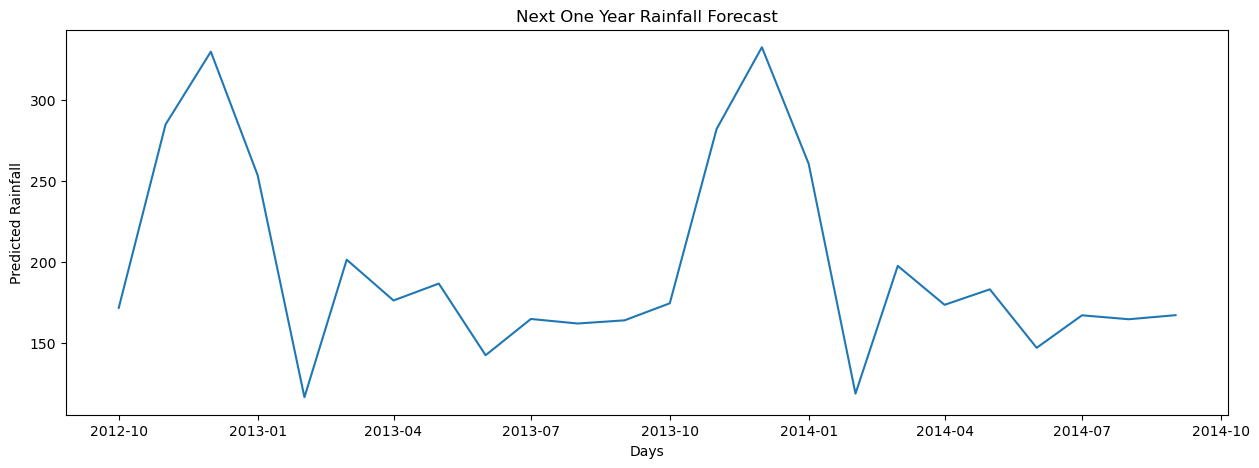

In [27]:
plt.figure(figsize=(15,5))

plt.plot(future_forecast)

plt.title("Next One Year Rainfall Forecast")

plt.xlabel("Days")

plt.ylabel("Predicted Rainfall")

plt.show()

In [28]:
monthly_max = df['total_rainfall'].resample('M').max()

print(monthly_max)

Date
1982-01-31    107.1
1982-02-28     27.8
1982-03-31    160.8
1982-04-30    157.0
1982-05-31    102.2
              ...  
2020-02-29     65.0
2020-03-31    108.8
2020-04-30    188.0
2020-05-31    255.6
2020-06-30    233.8
Freq: ME, Name: total_rainfall, Length: 462, dtype: float64


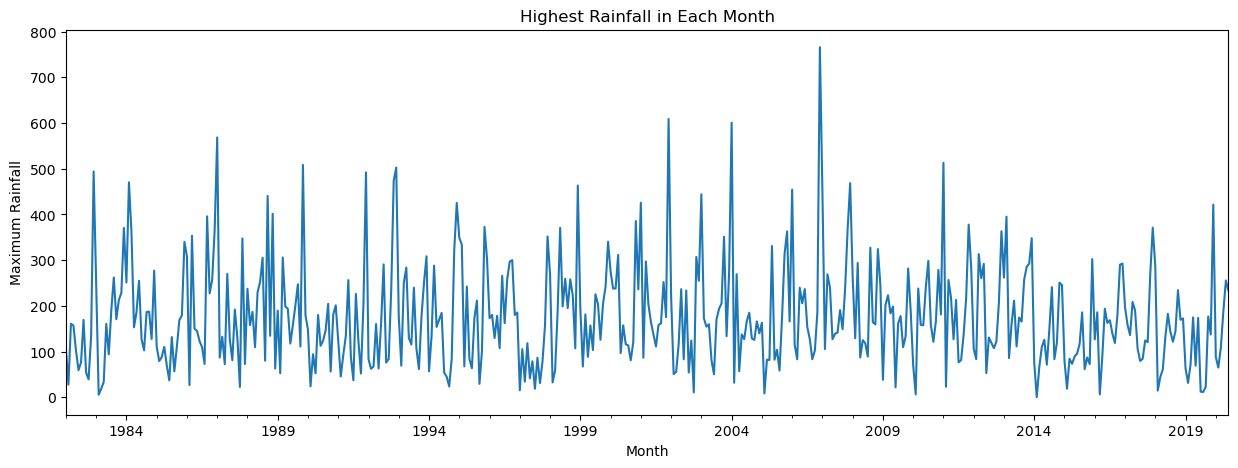

In [29]:
plt.figure(figsize=(15,5))

monthly_max.plot()

plt.title("Highest Rainfall in Each Month")

plt.xlabel("Month")

plt.ylabel("Maximum Rainfall")

plt.show()

In [30]:
forecast_df = pd.DataFrame({
    'Forecast': future_forecast
})

forecast_df.to_csv("future_rainfall_forecast.csv")

print("Forecast File Saved Successfully!")

Forecast File Saved Successfully!
